# Part B · NB3 — MAE   ·  `pavecrack1300-partb-mae`

**Course:** CSE 438 — Digital Image Processing · Dept. of CSE, **East West University** · Summer 2026
**Instructor:** _`Mohammad Rifat Ahmmad Rashid`_ · **Group:** _`C`_ · **Section:** _`<4>`_

| # | Name | Student ID |
|---|---|---|
| 1 | Mantasha Rahman Mahi | 2022-3-60-194 |
| 2 | Nazratan Mazumder Niha | 2022-3-60-328 | 
| 3 | Jannatul Ferdous Nabila | 2022-3-60-198 | 
| 4 | Sabiha Nusrat | 2022-1-60-303 |

**Method:** **MAE** — masked-patch reconstruction · backbone **ResNet-50**.
**Pipeline (Part B):** SSL-pretrain the encoder on the Part-A **train** split (unlabelled, 50 ep) → attach the
Part-A best decoder (**DeepLabV3 ASPP head**) → fine-tune on the Part-A **val** split (195 labelled, 50 ep) →
monitor + evaluate on the Part-A **test** split. *(# debugged/authored with AI assistance where noted.)*

**Attach:** raw **PaveCrack1300** + committed **Part-B data-prep output** (`partB_roles.json`). **GPU (T4) ON.**

In [1]:
# ---- setup & imports (version-pinned) ----
import os, gc, json, glob, time, math, random, copy, warnings
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "albumentations"], check=False)
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything()
print("torch", torch.__version__, "| device", DEVICE, "| GPU:",
      torch.cuda.get_device_name(0) if DEVICE == "cuda" else "-")

def amp_ctx():
    return torch.autocast("cuda", enabled=(DEVICE == "cuda"))
try:
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

torch 2.10.0+cu128 | device cuda | GPU: Tesla T4


In [2]:
# ---- load Part-B role mapping (from data-prep) + resolve raw paths ----
def _find(p):
    h = glob.glob(p, recursive=True); return h[0] if h else None
PB = json.load(open(_find("/kaggle/input/**/partB_roles.json")))
IMG_SIZE = PB["resolution"]; NUM_CLASSES = PB["num_classes"]; CLASS_NAMES = PB["class_names"]
train_recs, val_recs, test_recs = PB["train"], PB["val"], PB["test"]
print("roles:", PB["counts"], "| label-efficiency", PB["label_efficiency_ratio"])

IMGS  = glob.glob("/kaggle/input/**/images/images/*.jpg", recursive=True) or \
        glob.glob("/kaggle/input/**/images/**/*.jpg", recursive=True)
MASKS = glob.glob("/kaggle/input/**/masks/**/*.png", recursive=True)
PATH_BY_NAME = {Path(p).name: p for p in IMGS}
MASK_BY_NAME = {Path(p).name: p for p in MASKS}
assert PATH_BY_NAME and MASK_BY_NAME, "attach the raw PaveCrack1300 dataset"
WORK = Path("/kaggle/working"); WORK.mkdir(exist_ok=True)
IMAGENET_MEAN = (0.485, 0.456, 0.406); IMAGENET_STD = (0.229, 0.224, 0.225)

roles: {'train': 909, 'val': 195, 'test': 196} | label-efficiency 0.2145


In [3]:
# ---- datasets: SSL two-view (images only) · labelled seg · test ----
def _try(cls, *vs):
    last = None
    for kw in vs:
        try: return cls(**kw)
        except (TypeError, ValueError) as e: last = e
    raise RuntimeError(str(last))
import cv2
def _geom(p=0.5):
    if hasattr(A, "ShiftScaleRotate"):
        try: return A.ShiftScaleRotate(0.0625, 0.1, 15, border_mode=cv2.BORDER_REFLECT_101, p=p)
        except (TypeError, ValueError): pass
    return _try(A.Affine, dict(translate_percent=0.0625, scale=(0.9,1.1), rotate=(-15,15), p=p))

label_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(0.5), A.VerticalFlip(0.5),
                      A.RandomRotate90(0.5), _geom(0.5), A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
                      A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])
test_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])

class LabeledSeg(Dataset):
    def __init__(self, recs, aug): self.recs, self.aug = recs, aug
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        r = self.recs[i]
        img = np.array(Image.open(PATH_BY_NAME[r["image"]]).convert("RGB"))
        m = (np.array(Image.open(MASK_BY_NAME[r["mask"]])) > 0).astype("uint8")
        o = self.aug(image=img, mask=m); return o["image"], o["mask"].long(), r["sample_id"]

class SSLTwoView(Dataset):
    def __init__(self, recs, tf): self.recs, self.tf = recs, tf
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        img = Image.open(PATH_BY_NAME[self.recs[i]["image"]]).convert("RGB")
        return self.tf(img), self.tf(img)

val_loader  = DataLoader(LabeledSeg(val_recs,  label_tf), batch_size=8,  shuffle=True,  num_workers=2, drop_last=False)
test_loader = DataLoader(LabeledSeg(test_recs, test_tf),  batch_size=8,  shuffle=False, num_workers=2)
print("labelled(val):", len(val_recs), "| test:", len(test_recs), "| unlabelled(train):", len(train_recs))

labelled(val): 195 | test: 196 | unlabelled(train): 909


In [4]:
# ---- metrics + loss (same confusion-matrix source of truth as Part A) ----
class ConfMat:
    def __init__(s, n): s.n = n; s.mat = torch.zeros(n, n, dtype=torch.int64)
    def update(s, p, t):
        p = p.flatten(); t = t.flatten(); k = (t >= 0) & (t < s.n)
        s.mat += torch.bincount(s.n * t[k] + p[k], minlength=s.n**2).reshape(s.n, s.n).cpu()
    def compute(s):
        m = s.mat.double(); tp = m.diag(); fp = m.sum(0) - tp; fn = m.sum(1) - tp
        iou = tp / (tp + fp + fn).clamp(min=1e-9); dice = 2*tp / (2*tp + fp + fn).clamp(min=1e-9)
        return dict(iou=iou.tolist(), miou=iou.mean().item(), dice=dice.tolist(), mdice=dice.mean().item(),
                    pixel_acc=(tp.sum()/m.sum().clamp(min=1e-9)).item(),
                    mean_pixel_acc=(tp/m.sum(1).clamp(min=1e-9)).mean().item())
def per_image_iou(p, t, c=1):
    p = (p == c); t = (t == c); inter = int((p & t).sum()); union = int((p | t).sum())
    return inter/union if union else float("nan")
class DiceLoss(nn.Module):
    def forward(s, logits, tgt):
        pr = torch.softmax(logits, 1); oh = F.one_hot(tgt, logits.shape[1]).permute(0,3,1,2).float()
        d = (2*(pr*oh).sum((0,2,3)) + 1e-6) / ((pr+oh).sum((0,2,3)) + 1e-6); return 1 - d.mean()
class ComboLoss(nn.Module):
    def __init__(s, w=(0.56, 4.63)):
        super().__init__(); s.ce = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32)); s.d = DiceLoss()
    def forward(s, logits, tgt): return s.ce(logits, tgt) + s.d(logits, tgt)
criterion = ComboLoss().to(DEVICE)
print("metrics + Dice+CE loss ready")

metrics + Dice+CE loss ready


## Task B — MAE pretraining (ResNet-50 masked-autoencoder, 50 ep)
~75% of image patches are masked; the ResNet-50 encoder sees the corrupted image and a light transposed-conv
decoder reconstructs the original pixels (MSE). Only the **encoder** is transferred downstream.

  SSL ep 01 MAE recon 0.9149
  SSL ep 05 MAE recon 0.3033
  SSL ep 10 MAE recon 0.2727
  SSL ep 15 MAE recon 0.2579
  SSL ep 20 MAE recon 0.2464
  SSL ep 25 MAE recon 0.2421
  SSL ep 30 MAE recon 0.2381
  SSL ep 35 MAE recon 0.2282
  SSL ep 40 MAE recon 0.2266
  SSL ep 45 MAE recon 0.2243
  SSL ep 50 MAE recon 0.2212
MAE pretraining done: 4.3 min (0.09 min/ep)


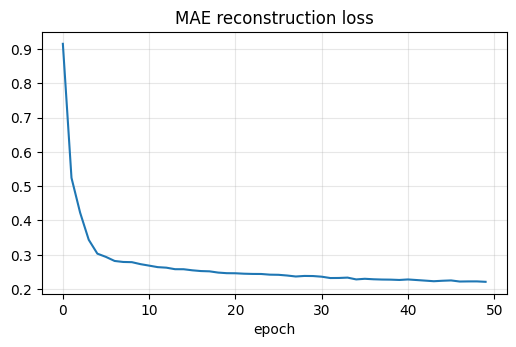

In [5]:
from torchvision.models import resnet50
mae_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE), antialias=True), T.RandomHorizontalFlip(0.5),
                    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
class SingleView(Dataset):
    def __init__(s, recs, tf): s.recs, s.tf = recs, tf
    def __len__(s): return len(s.recs)
    def __getitem__(s, i): return s.tf(Image.open(PATH_BY_NAME[s.recs[i]["image"]]).convert("RGB"))
ssl_loader = DataLoader(SingleView(train_recs, mae_tf), batch_size=48, shuffle=True, num_workers=2, drop_last=True)

MASK_PATCH = 16; MASK_RATIO = 0.75
def patch_mask(x):
    B, _, H, W = x.shape; ph, pw = H//MASK_PATCH, W//MASK_PATCH
    m = (torch.rand(B, 1, ph, pw, device=x.device) < MASK_RATIO).float()
    m = F.interpolate(m, size=(H, W), mode="nearest"); return x*(1-m), m
class MAEResNet(nn.Module):
    def __init__(s):
        super().__init__(); e = resnet50(weights=None); s.encoder = e
        s.stem = nn.Sequential(e.conv1, e.bn1, e.relu, e.maxpool)
        s.dec = nn.Sequential(
            nn.ConvTranspose2d(2048,512,4,2,1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512,256,4,2,1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,64,4,2,1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64,3,4,2,1))
    def feats(s, x):
        e = s.encoder; x = s.stem(x); x = e.layer1(x); x = e.layer2(x); x = e.layer3(x); return e.layer4(x)
    def forward(s, x): return s.dec(s.feats(x))

SSL_EPOCHS = 50
mae = MAEResNet().to(DEVICE); opt = torch.optim.AdamW(mae.parameters(), lr=1.5e-4, weight_decay=5e-2)
ssl_hist = []; t0 = time.time()
for ep in range(1, SSL_EPOCHS+1):
    mae.train(); run = 0.0
    for x in ssl_loader:
        x = x.to(DEVICE); xm, m = patch_mask(x); opt.zero_grad(set_to_none=True)
        with amp_ctx():
            rec = mae(xm); rec = F.interpolate(rec, size=x.shape[-2:], mode="bilinear", align_corners=False)
            loss = ((rec.float() - x.float())**2 * m).sum() / (m.sum()*3 + 1e-6)   # MSE (float32) on masked pixels
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); run += loss.item()
    ssl_hist.append(run/len(ssl_loader))
    if ep % 5 == 0 or ep == 1: print(f"  SSL ep {ep:02d} MAE recon {ssl_hist[-1]:.4f}")
ssl_minutes = (time.time()-t0)/60
print(f"MAE pretraining done: {ssl_minutes:.1f} min ({ssl_minutes/SSL_EPOCHS:.2f} min/ep)")
plt.figure(figsize=(6,3.4)); plt.plot(ssl_hist); plt.title("MAE reconstruction loss"); plt.xlabel("epoch"); plt.grid(alpha=.3)
plt.savefig(WORK/"MAE_pretrain_loss.png", dpi=110); plt.show()
pretrained_encoder = mae.encoder

In [6]:
# ---- attach DeepLabV3 ASPP head: transfer the SSL-pretrained ResNet-50 into deeplabv3_resnet50 ----
from torchvision.models.segmentation import deeplabv3_resnet50
def build_seg_from_resnet(encoder, frozen=False):
    model = deeplabv3_resnet50(weights=None, weights_backbone=None, num_classes=NUM_CLASSES, aux_loss=True)
    rep = model.backbone.load_state_dict(encoder.state_dict(), strict=False)   # ResNet-50 layers transfer; fc/proj ignored
    print("  transferred SSL encoder -> deeplab backbone | missing", len(rep.missing_keys), "unexpected", len(rep.unexpected_keys))
    if frozen:
        for p in model.backbone.parameters(): p.requires_grad_(False)
    return model.to(DEVICE)
def _is_encoder(name): return name.startswith("backbone.")
def seg_logits(model, x): return model(x)["out"]
def seg_train_forward(model, x, y):
    out = model(x); loss = criterion(out["out"], y) + 0.4*criterion(out["aux"], y); return loss, out["out"]

In [7]:
# ---- fine-tune (val split, 50 ep) · monitor test crack-IoU · checkpoint best ----
FT_EPOCHS = 50
def finetune(model, tag, enc_lr, dec_lr):
    enc_params = [p for n, p in model.named_parameters() if p.requires_grad and _is_encoder(n)]
    dec_params = [p for n, p in model.named_parameters() if p.requires_grad and not _is_encoder(n)]
    opt = torch.optim.AdamW([{"params": enc_params, "lr": enc_lr}, {"params": dec_params, "lr": dec_lr}], weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FT_EPOCHS)
    hist = defaultdict(list); best = -1; best_state = None; t0 = time.time()
    for ep in range(1, FT_EPOCHS+1):
        model.train(); run = 0.0
        for x, y, _ in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad(set_to_none=True)
            with amp_ctx(): loss, _ = seg_train_forward(model, x, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); run += loss.item()*x.size(0)
        sch.step()
        cm = ConfMat(NUM_CLASSES); model.eval(); vl = 0.0
        with torch.no_grad():
            for x, y, _ in test_loader:
                x = x.to(DEVICE)
                with amp_ctx(): lo = seg_logits(model, x)
                vl += criterion(lo, y.to(DEVICE)).item()*x.size(0); cm.update(lo.argmax(1).cpu(), y)
        met = cm.compute(); ci = met["iou"][1]
        hist["train_loss"].append(run/len(val_recs)); hist["test_loss"].append(vl/len(test_recs))
        hist["test_miou"].append(met["miou"]); hist["test_crack_iou"].append(ci)
        if ci > best: best = ci; best_ep = ep; best_state = copy.deepcopy(model.state_dict())
        if ep % 5 == 0 or ep == 1:
            print(f"  [{tag}] ep {ep:02d} train {hist['train_loss'][-1]:.3f} | test mIoU {met['miou']:.3f} crackIoU {ci:.3f}")
    model.load_state_dict(best_state)
    mins = (time.time()-t0)/60
    print(f"  [{tag}] done {mins:.1f} min | best test crack-IoU {best:.4f} @ ep {best_ep}")
    return model, hist, mins, best_ep

In [8]:
# ---- Task E (test metrics + confusion) + Task F (worst) + results.json ----
def evaluate_and_report(model, hist, mins, best_ep, tag="MAE"):
    cm = ConfMat(NUM_CLASSES); per = {}; model.eval()
    rec = {r["sample_id"]: r for r in test_recs}
    with torch.no_grad():
        for x, y, sids in test_loader:
            x = x.to(DEVICE)
            with amp_ctx(): pr = seg_logits(model, x).argmax(1).cpu()
            cm.update(pr, y)
            for b in range(x.size(0)): per[sids[b]] = per_image_iou(pr[b], y[b], 1)
    met = cm.compute()
    print(f"=== Task E — {tag} ===  mIoU {met['miou']:.4f} | crackIoU {met['iou'][1]:.4f} | "
          f"pixAcc {met['pixel_acc']:.4f} | Dice {met['mdice']:.4f}")
    # curves
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["train_loss"], label="fine-tune loss (val)"); ax[0].plot(hist["test_loss"], label="monitor loss (test)")
    ax[0].set_title(f"{tag} loss"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist["test_miou"], label="test mIoU"); ax[1].plot(hist["test_crack_iou"], label="test crack IoU")
    ax[1].set_title("downstream monitoring"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(WORK/f"{tag}_curves.png", dpi=110, bbox_inches="tight"); plt.show()
    # confusion
    M = cm.mat.numpy()
    plt.figure(figsize=(4,3.4)); plt.imshow(M, cmap="Blues")
    for r_ in range(2):
        for c_ in range(2): plt.text(c_, r_, M[r_,c_], ha="center", va="center")
    plt.xticks([0,1], CLASS_NAMES); plt.yticks([0,1], CLASS_NAMES); plt.xlabel("pred"); plt.ylabel("true")
    plt.title(f"{tag} confusion"); plt.tight_layout(); plt.savefig(WORK/f"{tag}_confusion.png", dpi=110); plt.show()
    # Task F worst
    valid = {k: v for k, v in per.items() if not math.isnan(v)}
    worst = sorted(valid, key=valid.get)[:6]
    fig, ax = plt.subplots(len(worst), 3, figsize=(9, 3*len(worst))); ax = np.atleast_2d(ax)
    for i, sid in enumerate(worst):
        r = rec[sid]; img = np.array(Image.open(PATH_BY_NAME[r["image"]]).convert("RGB"))
        gt = (np.array(Image.open(MASK_BY_NAME[r["mask"]])) > 0).astype(np.uint8)
        x = test_tf(image=img, mask=gt)["image"].unsqueeze(0).to(DEVICE)
        with torch.no_grad(), amp_ctx(): pr = seg_logits(model, x).argmax(1)[0].cpu().numpy()
        ax[i,0].imshow(img); ax[i,0].set_title(f"{sid} IoU={valid[sid]:.2f}", fontsize=8)
        ax[i,1].imshow(cv2.resize(gt,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_NEAREST), cmap="gray"); ax[i,1].set_title("GT", fontsize=8)
        ax[i,2].imshow(pr, cmap="gray"); ax[i,2].set_title("pred", fontsize=8)
        for a in ax[i]: a.axis("off")
    plt.suptitle(f"Task F — worst test images · {tag}", y=1.005); plt.tight_layout()
    plt.savefig(WORK/f"{tag}_worst.png", dpi=100); plt.show()
    # results.json (merge)
    rp = WORK/"results_partB.json"; res = json.load(open(rp)) if rp.exists() else {}
    res[tag] = dict(method=tag, params_M=round(sum(p.numel() for p in model.parameters())/1e6, 2), miou=met["miou"], per_class_iou=met["iou"],
                    pixel_acc=met["pixel_acc"], mdice=met["mdice"], crack_iou=met["iou"][1], crack_dice=met["dice"][1],
                    finetune_minutes=round(mins,1), best_epoch=int(best_ep), n_labelled=len(val_recs),
                    per_image_crack_iou=valid, confusion=cm.mat.tolist())
    json.dump(res, open(rp, "w"), indent=2)
    print("results_partB.json now has:", list(res.keys())); return met

  transferred SSL encoder -> deeplab backbone | missing 0 unexpected 2
  [MAE] ep 01 train 1.513 | test mIoU 0.570 crackIoU 0.331
  [MAE] ep 05 train 1.008 | test mIoU 0.643 crackIoU 0.415
  [MAE] ep 10 train 0.925 | test mIoU 0.675 crackIoU 0.457
  [MAE] ep 15 train 0.912 | test mIoU 0.674 crackIoU 0.457
  [MAE] ep 20 train 0.874 | test mIoU 0.666 crackIoU 0.451
  [MAE] ep 25 train 0.860 | test mIoU 0.667 crackIoU 0.452
  [MAE] ep 30 train 0.870 | test mIoU 0.697 crackIoU 0.492
  [MAE] ep 35 train 0.818 | test mIoU 0.679 crackIoU 0.469
  [MAE] ep 40 train 0.816 | test mIoU 0.688 crackIoU 0.481
  [MAE] ep 45 train 0.815 | test mIoU 0.686 crackIoU 0.478
  [MAE] ep 50 train 0.781 | test mIoU 0.687 crackIoU 0.479
  [MAE] done 4.5 min | best test crack-IoU 0.4915 @ ep 30
=== Task E — MAE ===  mIoU 0.6971 | crackIoU 0.4915 | pixAcc 0.9111 | Dice 0.8040


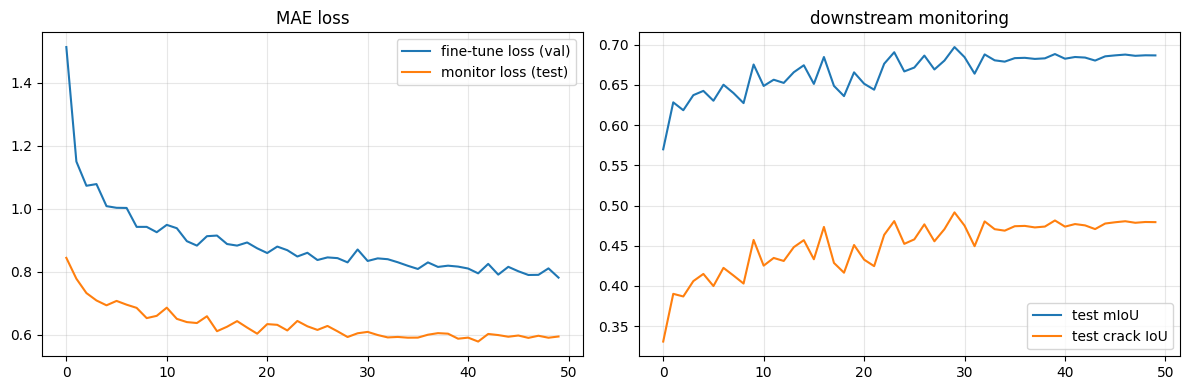

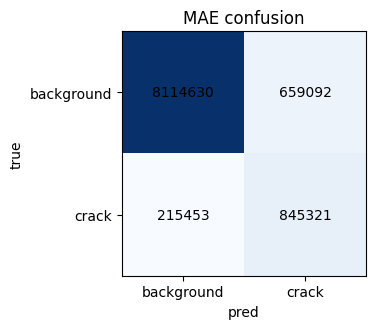

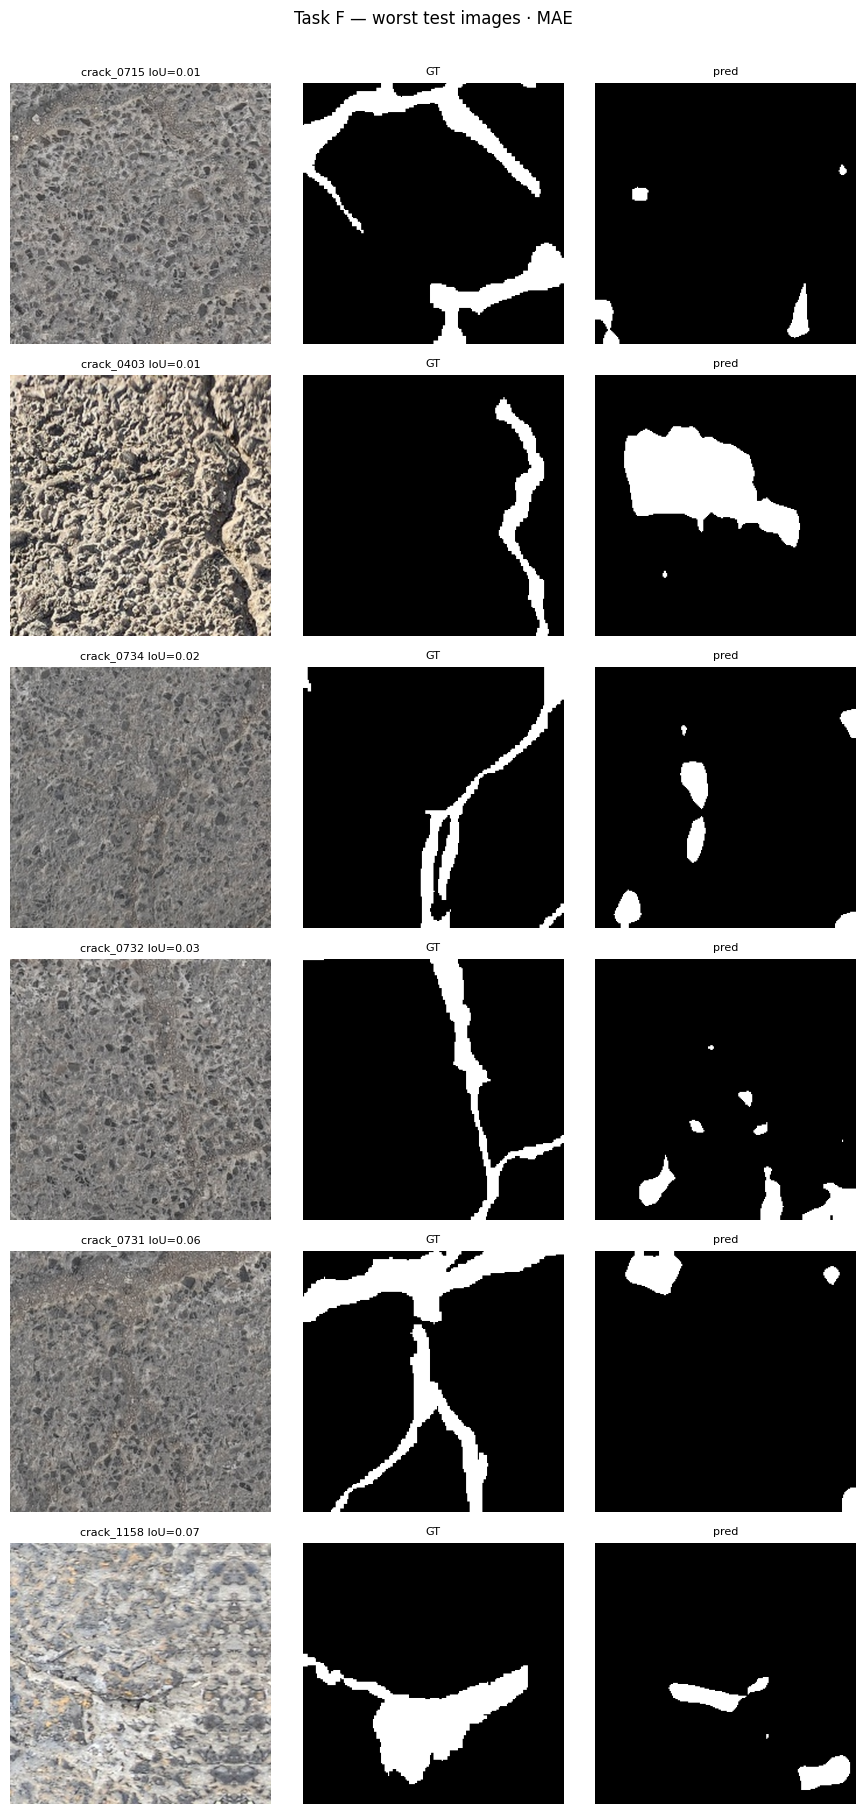

results_partB.json now has: ['MAE']


{'iou': [0.9027113166669911, 0.4915039892642799],
 'miou': 0.6971076529656355,
 'dice': [0.9488683950734939, 0.6590716388317889],
 'mdice': 0.8039700169526414,
 'pixel_acc': 0.9110737347394315,
 'mean_pixel_acc': 0.8608848103735667}

In [9]:
# ---- full fine-tune (differential LR: low encoder LR, higher decoder LR) ----
model = build_seg_from_resnet(pretrained_encoder, frozen=False)
model, hist, mins, best_ep = finetune(model, "MAE", enc_lr=1e-5, dec_lr=1e-3)
evaluate_and_report(model, hist, mins, best_ep, tag="MAE")

## MAE complete
SSL pretraining (50 ep) + downstream fine-tuning (50 ep on 195 labelled images) done; test metrics + worst-image
error analysis produced; appended to `results_partB.json`. **Commit** so the final-comparison notebook can pull it.